# 03 — Model Comparison

All five proposal models are tuned and compared here.

**Key design choices that prevent bias:**
- Hyperparameter tuning uses a **dedicated inner CV** (`make_tuning_cv` → StratifiedKFold 5-fold).
- Performance evaluation uses a **separate outer CV** (`make_eval_cv_splits` → 5×2 RepeatedStratifiedKFold).
- These two CV objects are completely independent — no double-dipping.
- The same eval-splits list is reused across all models so every model sees identical folds.

Results are saved to `results/` and the best hyperparameters are serialised to disk
for Notebook 04 to load (no re-tuning).


In [15]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [16]:
import pandas as pd
from sklearn.base import clone

from src.config import get_project_paths, N_CANDIDATES
from src.data import (
    load_processed_dataset, prepare_binary_target,
    split_features_target, create_train_test_split,
    compare_train_test_distribution,
)
from src.preprocessing import create_preprocessor
from src.models import get_comparison_models, get_comparison_param_grids
from src.evaluation import (
    make_eval_cv_splits,
    tune_models,
    run_cross_validation,
    run_test_evaluation,
    add_selection_score,
    save_candidate_models,
    save_best_params,
)
from src.stats import (
    run_wilcoxon_multiple_metrics,
    run_mcnemar_pairwise,
    print_significance_summary,
)
from src.plots import (
    save_metric_bar_plot,
    save_confusion_matrices,
    save_pvalue_heatmap,
)

## 1. Load data

In [17]:
paths = get_project_paths()
tables_dir  = paths["tables_dir"]
figures_dir = paths["figures_dir"]
models_dir  = paths["models_dir"]

df = load_processed_dataset(paths["processed_data_path"])
df_model = prepare_binary_target(df)
X, y = split_features_target(df_model)
X_train, X_test, y_train, y_test = create_train_test_split(X, y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
compare_train_test_distribution(y_train, y_test)

Train: (456, 10) | Test: (114, 10)


,train_proportion,test_proportion
target,,
0,0.287281,0.289474
1,0.712719,0.710526


## 2. Preprocessing (built from X_train)

In [18]:
# FIXED: pass X_train, not full X
preprocessor, numeric_features, categorical_features = create_preprocessor(X_train)

## 3. Evaluation CV splits (generated once, reused across all models)

In [19]:
# These 10 splits are used ONLY for cross_validate — never passed to GridSearchCV.
eval_cv_splits = make_eval_cv_splits(X_train, y_train, random_state=42)
print("Number of eval CV splits:", len(eval_cv_splits))

Number of eval CV splits: 10


## 4. Hyperparameter tuning (inner CV = StratifiedKFold 5, separate from eval splits)

In [20]:
comparison_models = get_comparison_models()
param_grids = get_comparison_param_grids()

tuning_df, tuned_estimators, best_params = tune_models(
    models=comparison_models,
    param_grids=param_grids,
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
)

tuning_df.to_csv(tables_dir / "nb03_tuning_results.csv", index=False)
tuning_df[["Model", "Best CV Score (Balanced Acc)", "Best Params", "Tuning Time (s)"]]

Tuning: Logistic Regression
Tuning: SVM
Tuning: Random Forest
Tuning: Gradient Boosting
Tuning: MLP


,Model,Best CV Score (Balanced Acc),Best Params,Tuning Time (s)
0,Logistic Regression,0.671140,"{'classifier__C': 10.0, 'classifier__class_wei...",4.668974
1,SVM,0.681054,"{'classifier__C': 0.5, 'classifier__class_weig...",0.294986
2,Random Forest,0.664644,"{'classifier__class_weight': 'balanced', 'clas...",2.025344
3,Gradient Boosting,0.599345,"{'classifier__learning_rate': 0.1, 'classifier...",1.276002
4,MLP,0.570655,"{'classifier__alpha': 0.0001, 'classifier__hid...",0.315843


## 5. 5×2 CV evaluation (outer eval splits, no overlap with tuning)

In [21]:
cv_summary_df, raw_cv_scores = run_cross_validation(
    estimators=tuned_estimators,
    X_train=X_train,
    y_train=y_train,
    eval_cv_splits=eval_cv_splits,
)

cv_summary_df = add_selection_score(cv_summary_df)
cv_summary_df = cv_summary_df.sort_values("Selection Score", ascending=False)
cv_summary_df.to_csv(tables_dir / "nb03_cv_results.csv", index=False)
cv_summary_df.round(4)

5×2 CV evaluation: Logistic Regression
5×2 CV evaluation: SVM
5×2 CV evaluation: Random Forest
5×2 CV evaluation: Gradient Boosting
5×2 CV evaluation: MLP


,Model,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc Auc Mean,CV Roc Auc Std,CV Average Precision Mean,CV Average Precision Std,CV Mcc Mean,CV Mcc Std,Selection Score
3,Gradient Boosting,0.6772,0.0160,0.5777,0.0203,0.7547,0.0140,0.8117,0.0378,0.7815,0.0152,0.6739,0.0240,0.8413,0.0163,0.1667,0.0360,0.7112
2,Random Forest,0.6750,0.0243,0.6476,0.0154,0.8099,0.0139,0.7120,0.0528,0.7564,0.0271,0.7154,0.0269,0.8716,0.0186,0.2781,0.0279,0.7079
0,Logistic Regression,0.6232,0.0281,0.6619,0.0218,0.8529,0.0236,0.5711,0.0524,0.6822,0.0354,0.7162,0.0238,0.8739,0.0118,0.2948,0.0394,0.6578
1,SVM,0.5956,0.0295,0.6730,0.0269,0.8959,0.0322,0.4911,0.0483,0.6324,0.0393,0.7128,0.0333,0.8666,0.0202,0.3222,0.0489,0.6273
4,MLP,0.4360,0.0531,0.5652,0.0200,0.8519,0.0551,0.2616,0.1117,0.3849,0.1162,0.6105,0.0318,0.8074,0.0192,0.1492,0.0394,0.4556


## 6. Independent test-set evaluation

In [22]:
test_df, trained_estimators, predictions = run_test_evaluation(
    estimators=tuned_estimators,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)

test_df = add_selection_score(test_df)
test_df = test_df.sort_values("Selection Score", ascending=False)
test_df.to_csv(tables_dir / "nb03_test_results.csv", index=False)
test_df.round(4)

Test evaluation: Logistic Regression
              precision    recall  f1-score   support

           0       0.51      0.85      0.64        33
           1       0.92      0.67      0.77        81

    accuracy                           0.72       114
   macro avg       0.71      0.76      0.70       114
weighted avg       0.80      0.72      0.73       114

Confusion Matrix:
 [[28  5]
 [27 54]]
Test evaluation: SVM
              precision    recall  f1-score   support

           0       0.51      0.88      0.64        33
           1       0.93      0.65      0.77        81

    accuracy                           0.72       114
   macro avg       0.72      0.77      0.71       114
weighted avg       0.81      0.72      0.73       114

Confusion Matrix:
 [[29  4]
 [28 53]]
Test evaluation: Random Forest
              precision    recall  f1-score   support

           0       0.52      0.76      0.62        33
           1       0.88      0.72      0.79        81

    accuracy     

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Selection Score
3,Gradient Boosting,0.7281,0.5572,0.7358,0.9630,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.2214,0.0048,0.7755
4,MLP,0.7281,0.5842,0.7500,0.9259,0.2424,0.8287,0.2326,8,25,6,75,0.7568,0.8960,0.0462,0.0028,0.7739
2,Random Forest,0.7281,0.7368,0.8788,0.7160,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.2185,0.0081,0.7639
1,SVM,0.7193,0.7666,0.9298,0.6543,0.8788,0.7681,0.4835,29,4,28,53,0.8103,0.9285,0.0279,0.0051,0.7498
0,Logistic Regression,0.7193,0.7576,0.9153,0.6667,0.8485,0.7714,0.4675,28,5,27,54,0.7999,0.9259,0.0151,0.0044,0.7489


## 7. Statistical significance tests

### 7a. Wilcoxon signed-rank test (CV fold scores)

For each pair of models, tests H₀: *the two classifiers produce the same distribution
of fold scores* using a non-parametric paired test on the 10 CV scores.

### 7b. McNemar's test (test-set predictions)

Tests H₀: *the two classifiers make the same number of errors* on the held-out test set.

In [23]:
wilcoxon_df = run_wilcoxon_multiple_metrics(
    raw_cv_scores,
    metrics=["recall", "balanced_accuracy", "f1", "roc_auc"],
)
wilcoxon_df.to_csv(tables_dir / "nb03_wilcoxon_tests.csv", index=False)
wilcoxon_df.round(4)

,Model A,Model B,Metric,Mean A,Mean B,W Statistic,p-value,Significant (α=0.05)
10,Logistic Regression,MLP,balanced_accuracy,0.6619,0.5652,0.0,0.0020,True
11,Logistic Regression,Gradient Boosting,balanced_accuracy,0.6619,0.5777,0.0,0.0020,True
12,SVM,MLP,balanced_accuracy,0.6730,0.5652,0.0,0.0020,True
13,SVM,Gradient Boosting,balanced_accuracy,0.6730,0.5777,0.0,0.0020,True
14,Random Forest,Gradient Boosting,balanced_accuracy,0.6476,0.5777,0.0,0.0020,True
15,Random Forest,MLP,balanced_accuracy,0.6476,0.5652,0.0,0.0020,True
16,SVM,Random Forest,balanced_accuracy,0.6730,0.6476,6.0,0.0273,True
17,Logistic Regression,Random Forest,balanced_accuracy,0.6619,0.6476,13.0,0.1602,False
18,Gradient Boosting,MLP,balanced_accuracy,0.5777,0.5652,16.0,0.2754,False
19,Logistic Regression,SVM,balanced_accuracy,0.6619,0.6730,19.0,0.4316,False


In [ ]:
mcnemar_df = run_mcnemar_pairwise(predictions, y_test)
mcnemar_df.to_csv(tables_dir / "nb03_mcnemar_tests.csv", index=False)
mcnemar_df.round(4)

,Model A,Model B,"b (A wrong, B right)","c (A right, B wrong)",Chi2,p-value,Significant (α=0.05)
0,Logistic Regression,SVM,4,4,0.1250,0.7237,False
1,Gradient Boosting,MLP,9,9,0.0556,0.8137,False
2,Random Forest,MLP,20,20,0.0250,0.8744,False
3,Random Forest,Gradient Boosting,22,22,0.0227,0.8802,False
4,Logistic Regression,MLP,21,20,0.0000,1.0000,False
5,SVM,Random Forest,8,7,0.0000,1.0000,False
6,Logistic Regression,Gradient Boosting,25,24,0.0000,1.0000,False
7,Logistic Regression,Random Forest,8,7,0.0000,1.0000,False
8,SVM,MLP,22,21,0.0000,1.0000,False
9,SVM,Gradient Boosting,25,24,0.0000,1.0000,False


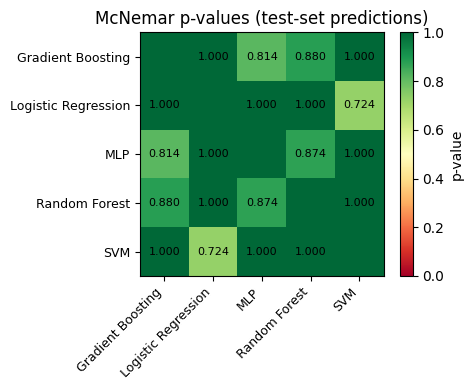

In [ ]:
# p-value heatmap for Recall (McNemar)
save_pvalue_heatmap(
    mcnemar_df,
    model_col_a="Model A",
    model_col_b="Model B",
    pval_col="p-value",
    figures_dir=figures_dir,
    file_name="mcnemar_pvalue_heatmap.png",
    title="McNemar p-values (test-set predictions)",
)

## 8. Confusion matrices and metric plots

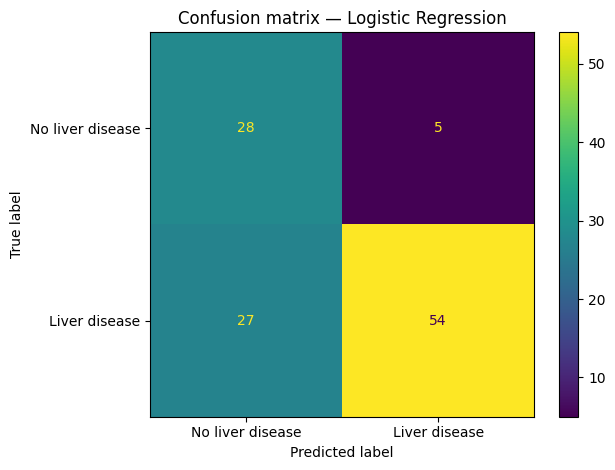

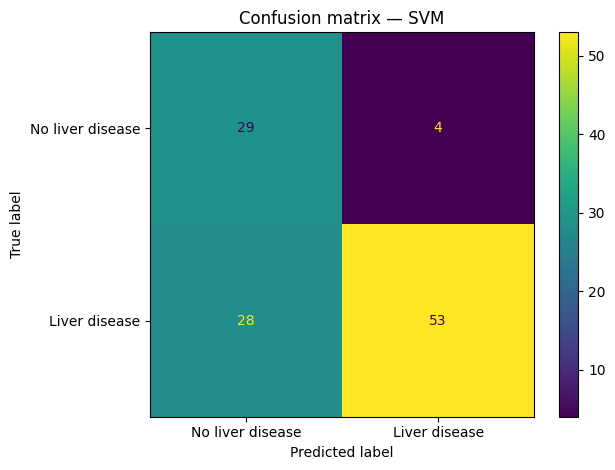

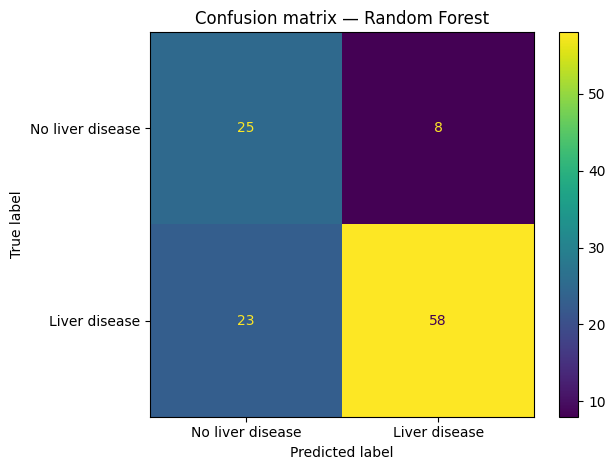

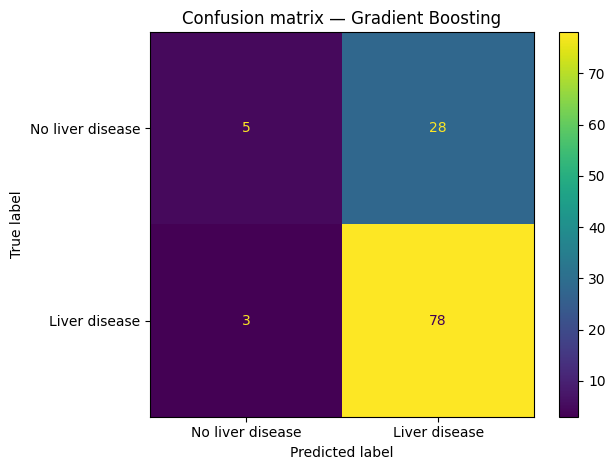

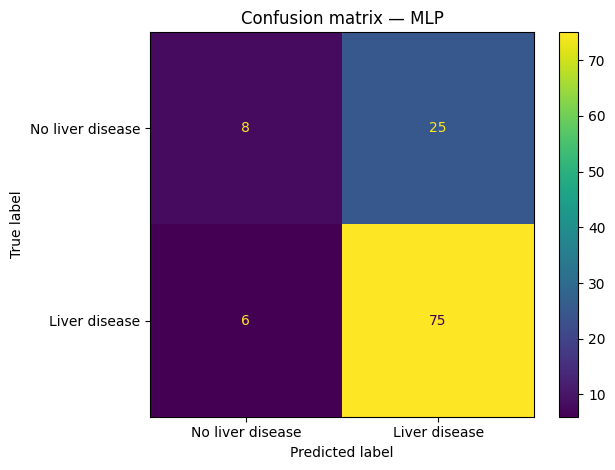

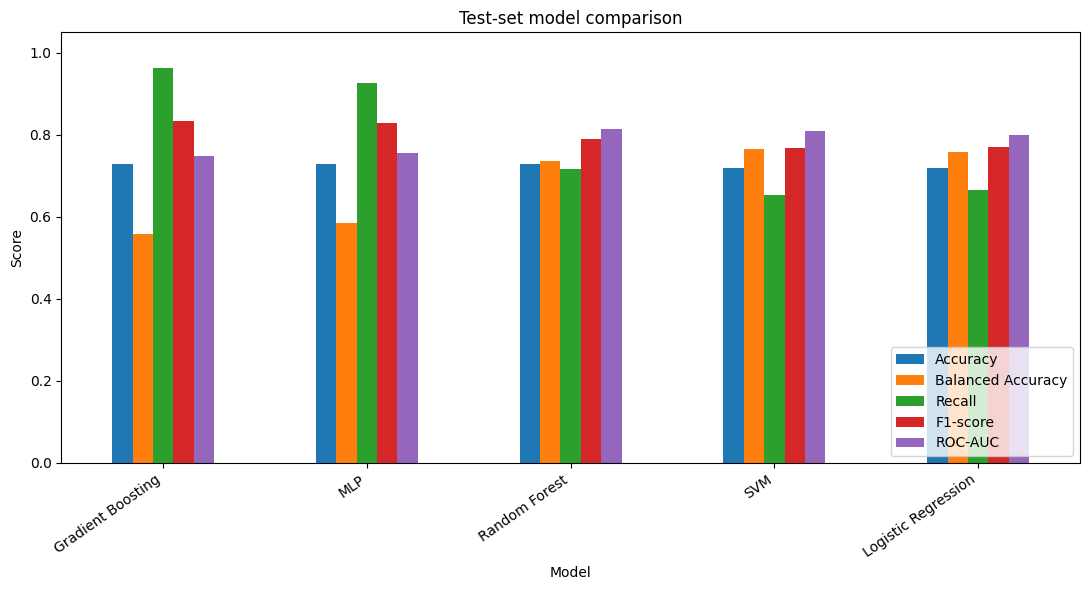

In [ ]:
save_confusion_matrices(trained_estimators, X_test, y_test, figures_dir)
save_metric_bar_plot(
    test_df,
    metrics=["Accuracy", "Balanced Accuracy", "Recall", "F1-score", "ROC-AUC"],
    figures_dir=figures_dir,
    file_name="nb03_model_comparison.png",
    title="Test-set model comparison",
)

## 9. Data-driven candidate selection

The top `N_CANDIDATES` models by Selection Score (mean of Recall, F1, Balanced Accuracy,
ROC-AUC on the 5×2 CV) are carried forward to Notebook 04 for deeper analysis.
This selection is made from the actual CV results — not hard-coded.

In [ ]:
candidate_names = (
    cv_summary_df.sort_values("Selection Score", ascending=False)
    .head(N_CANDIDATES)["Model"]
    .tolist()
)
print("Candidate models selected for NB04:", candidate_names)

# Save unfitted clones with best hyperparameters for NB04
unfitted_candidates = {
    name: clone(tuned_estimators[name])
    for name in candidate_names
}
save_candidate_models(unfitted_candidates, models_dir)
save_best_params({name: best_params[name] for name in candidate_names}, models_dir)

cv_summary_df[cv_summary_df["Model"].isin(candidate_names)].round(4)

Candidate models selected for NB04: ['Gradient Boosting', 'Random Forest']
Candidate models saved → C:\lfd_project\results\models\candidate_models.pkl
Best params saved → C:\lfd_project\results\models\best_params.json


,Model,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc Auc Mean,CV Roc Auc Std,CV Average Precision Mean,CV Average Precision Std,CV Mcc Mean,CV Mcc Std,Selection Score
3,Gradient Boosting,0.6772,0.0160,0.5777,0.0203,0.7547,0.0140,0.8117,0.0378,0.7815,0.0152,0.6739,0.0240,0.8413,0.0163,0.1667,0.0360,0.7112
2,Random Forest,0.6750,0.0243,0.6476,0.0154,0.8099,0.0139,0.7120,0.0528,0.7564,0.0271,0.7154,0.0269,0.8716,0.0186,0.2781,0.0279,0.7079


## Summary

All five models were tuned with a dedicated inner CV (StratifiedKFold 5-fold) and
evaluated with a separate 5×2 outer CV. Statistical tests quantify whether observed
differences are significant. Candidate models are selected data-driven and saved
for deep analysis in Notebook 04.